<a href="https://colab.research.google.com/github/Karthik2821/self-pruning/blob/main/self_pruning_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.10.0+cu128
GPU available: True
Device: Tesla T4


In [ ]:
!pip install -q torch torchvision matplotlib numpy

Using device: cuda

  λ = 1e-05  |  epochs=30  |  lr=0.001


100%|██████████| 170M/170M [00:05<00:00, 29.2MB/s]


  Epoch   1/30 | loss=20.2108 | test_acc=42.97% | sparsity=0.0%
  Epoch   5/30 | loss=14.0521 | test_acc=51.97% | sparsity=0.0%
  Epoch  10/30 | loss=9.6745 | test_acc=56.07% | sparsity=0.0%
  Epoch  15/30 | loss=7.6089 | test_acc=58.76% | sparsity=0.0%
  Epoch  20/30 | loss=6.6548 | test_acc=60.23% | sparsity=0.0%
  Epoch  25/30 | loss=6.2744 | test_acc=61.19% | sparsity=0.0%
  Epoch  30/30 | loss=6.1881 | test_acc=61.48% | sparsity=0.0%

  ✓ Final test accuracy : 61.48%
  ✓ Final sparsity      : 0.00%

  λ = 0.0001  |  epochs=30  |  lr=0.001
  Epoch   1/30 | loss=184.3093 | test_acc=41.98% | sparsity=0.0%
  Epoch   5/30 | loss=117.6633 | test_acc=50.83% | sparsity=0.0%
  Epoch  10/30 | loss=69.0258 | test_acc=56.29% | sparsity=0.0%
  Epoch  15/30 | loss=46.8426 | test_acc=57.78% | sparsity=0.0%
  Epoch  20/30 | loss=36.9954 | test_acc=60.33% | sparsity=0.0%
  Epoch  25/30 | loss=33.1647 | test_acc=61.28% | sparsity=0.0%
  Epoch  30/30 | loss=32.3707 | test_acc=61.25% | sparsity=0.0%


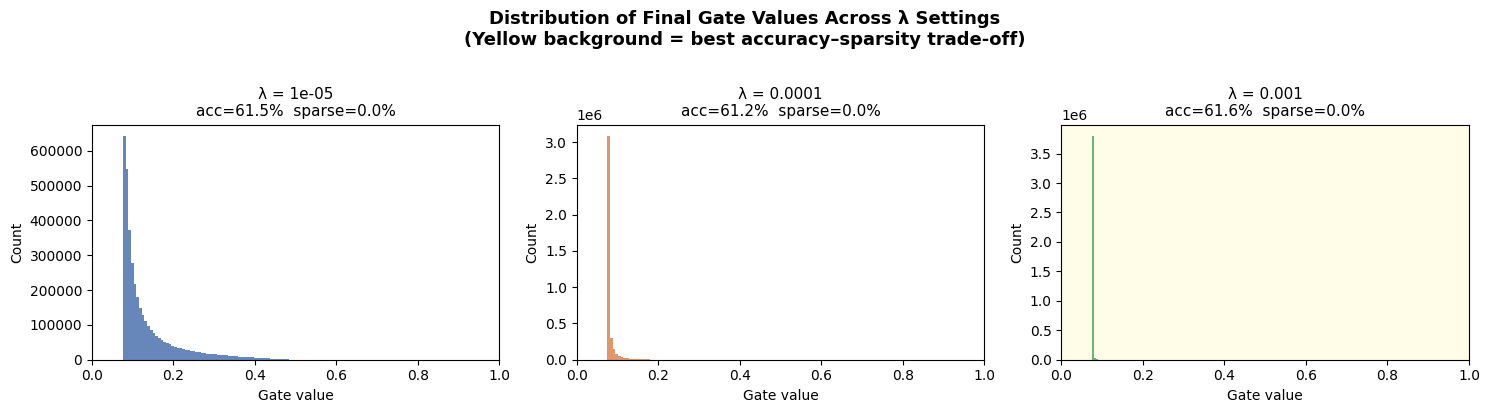

In [ ]:
"""
Self-Pruning Neural Network on CIFAR-10

Implements a feed-forward network with learnable gate parameters
that encourage weight sparsity via an L1 penalty on sigmoid gates.

Parts:
  1. PrunableLinear  - custom linear layer with gate_scores
  2. Loss formulation - CrossEntropy + λ * L1(gates)
  3. Training & evaluation loop with λ comparison
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────────────────────
# PART 1 — PrunableLinear
# ─────────────────────────────────────────────────────────────

class PrunableLinear(nn.Module):

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Standard weight & bias — same initialisation as nn.Linear
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # One gate score per weight element (same shape)
        # Initialised to 0  →  sigmoid(0) = 0.5  (half-open gates at start)
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        # Kaiming uniform init for the weights (matches nn.Linear default)
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Step 1: convert raw scores to gates ∈ (0, 1)
        gates = torch.sigmoid(self.gate_scores)

        # Step 2: element-wise gate the weights
        pruned_weights = self.weight * gates

        # Step 3: standard affine transform  (gradients flow through both)
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self) -> torch.Tensor:
        """Return the current gate values (detached from graph)."""
        return torch.sigmoid(self.gate_scores).detach()

    def extra_repr(self) -> str:
        return f"in={self.in_features}, out={self.out_features}"


# ─────────────────────────────────────────────────────────────
# Network definition
# ─────────────────────────────────────────────────────────────

class PrunableNet(nn.Module):

    def __init__(self):
        super().__init__()
        # CIFAR-10: 3 × 32 × 32 = 3072 input features
        self.net = nn.Sequential(
            PrunableLinear(3072, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            PrunableLinear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            PrunableLinear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            PrunableLinear(128, 10),   # output logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)    # flatten image
        return self.net(x)

    def prunable_layers(self):
        """Yield every PrunableLinear sub-module."""
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                yield module


# ─────────────────────────────────────────────────────────────
# PART 2 — Loss formulation
# ─────────────────────────────────────────────────────────────

def sparsity_loss(model: PrunableNet) -> torch.Tensor:

    total = torch.tensor(0.0, device=next(model.parameters()).device)
    for layer in model.prunable_layers():
        gates = torch.sigmoid(layer.gate_scores)
        total = total + gates.sum()
    return total


def total_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    model: PrunableNet,
    lam: float,
) -> torch.Tensor:

    cls_loss = F.cross_entropy(logits, targets)
    sp_loss  = sparsity_loss(model)
    return cls_loss + lam * sp_loss


# ─────────────────────────────────────────────────────────────
# PART 3 — Data, training loop, evaluation
# ─────────────────────────────────────────────────────────────

def get_dataloaders(batch_size: int = 256):

    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_ds = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader


def train_one_epoch(
    model: PrunableNet,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    lam: float,
    device: torch.device,
) -> float:

    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = total_loss(logits, labels, model, lam)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


@torch.no_grad()
def evaluate(model: PrunableNet, loader: DataLoader, device: torch.device) -> float:
    """Return accuracy on the given DataLoader."""
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds   = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100.0 * correct / total


def compute_sparsity(model: PrunableNet, threshold: float = 1e-2) -> float:

    all_gates = torch.cat([layer.get_gates().flatten() for layer in model.prunable_layers()])
    pruned    = (all_gates < threshold).sum().item()
    return 100.0 * pruned / all_gates.numel()


def all_gate_values(model: PrunableNet) -> np.ndarray:
    gates = [layer.get_gates().flatten().cpu().numpy() for layer in model.prunable_layers()]
    return np.concatenate(gates)


def run_experiment(
    lam: float,
    device: torch.device,
    epochs: int = 30,
    lr: float = 1e-3,
    batch_size: int = 256,
) -> dict:

    print(f"\n{'='*55}")
    print(f"  λ = {lam}  |  epochs={epochs}  |  lr={lr}")
    print(f"{'='*55}")

    train_loader, test_loader = get_dataloaders(batch_size)

    model     = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(1, epochs + 1):
        avg_loss = train_one_epoch(model, train_loader, optimizer, lam, device)
        scheduler.step()
        if epoch % 5 == 0 or epoch == 1:
            acc = evaluate(model, test_loader, device)
            sp  = compute_sparsity(model)
            print(f"  Epoch {epoch:3d}/{epochs} | loss={avg_loss:.4f} | "
                  f"test_acc={acc:.2f}% | sparsity={sp:.1f}%")

    final_acc      = evaluate(model, test_loader, device)
    final_sparsity = compute_sparsity(model)
    gates          = all_gate_values(model)

    print(f"\n  ✓ Final test accuracy : {final_acc:.2f}%")
    print(f"  ✓ Final sparsity      : {final_sparsity:.2f}%")

    return {
        "lam"      : lam,
        "accuracy" : final_acc,
        "sparsity" : final_sparsity,
        "gates"    : gates,
    }


def plot_gate_distribution(results: list[dict], best_idx: int, save_path: str = "gate_distribution.png"):

    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]

    colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    for i, (res, ax) in enumerate(zip(results, axes)):
        ax.hist(res["gates"], bins=80, color=colours[i % len(colours)],
                edgecolor="none", alpha=0.85)
        ax.set_title(f"λ = {res['lam']}\nacc={res['accuracy']:.1f}%  sparse={res['sparsity']:.1f}%",
                     fontsize=11)
        ax.set_xlabel("Gate value", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_xlim(0, 1)
        if i == best_idx:
            ax.set_facecolor("#FFFDE7")   # highlight best model panel

    fig.suptitle("Distribution of Final Gate Values Across λ Settings\n"
                 "(Yellow background = best accuracy–sparsity trade-off)",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved → {save_path}")
    plt.show()


def print_results_table(results: list[dict]):
    """Print a formatted summary table to stdout."""
    print("\n" + "─" * 52)
    print(f"{'λ':>10}  {'Test Acc (%)':>14}  {'Sparsity (%)':>14}")
    print("─" * 52)
    for r in results:
        print(f"{r['lam']:>10.4f}  {r['accuracy']:>14.2f}  {r['sparsity']:>14.2f}")
    print("─" * 52)


# ─────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # ── Three λ values: low / medium / high ──────────────────
    lambdas = [1e-5, 1e-4, 1e-3]
    epochs  = 30
    results = []
    for lam in lambdas:
        res = run_experiment(lam=lam, device=device, epochs=epochs)
        results.append(res)

    # ── Summary table ─────────────────────────────────────────
    print_results_table(results)

    # ── Pick "best" as highest accuracy (or balance if preferred) ──
    best_idx = max(range(len(results)), key=lambda i: results[i]["accuracy"])

    # ── Gate distribution plot ────────────────────────────────
    plot_gate_distribution(results, best_idx, save_path="gate_distribution.png")
